# Explore here

## Primero importaré pandas y extraeré el archivo CSV y como vamos a trabjara una ARIMA importamos PMDARIMA

In [9]:
import pandas as pd

df = pd.read_csv('../data/raw/acea-water-prediction/Aquifer_Auser.csv')

df

,Date,Rainfall_Gallicano,Rainfall_Pontetetto,Rainfall_Monte_Serra,Rainfall_Orentano,Rainfall_Borgo_a_Mozzano,Rainfall_Piaggione,Rainfall_Calavorno,Rainfall_Croce_Arcana,Rainfall_Tereglio_Coreglia_Antelminelli,...,Temperature_Monte_Serra,Temperature_Ponte_a_Moriano,Temperature_Lucca_Orto_Botanico,Volume_POL,Volume_CC1,Volume_CC2,Volume_CSA,Volume_CSAL,Hydrometry_Monte_S_Quirico,Hydrometry_Piaggione
0,05/03/1998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00,0.0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,06/03/1998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00,0.0,10.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,07/03/1998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.20,0.0,10.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,08/03/1998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,11.40,0.0,13.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,09/03/1998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,11.40,0.0,12.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8149,26/06/2020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,20.75,0.0,23.75,-7189.406533,-7847.900,-9183.433333,-6115.40,-3158.0,0.20,-1.03
8150,27/06/2020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,21.35,0.0,24.30,-7189.406533,-7847.900,-9183.433333,-6115.40,-3158.0,0.21,-1.03
8151,28/06/2020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,21.75,0.0,24.55,-6829.936207,-7455.505,-8724.261667,-5809.63,-3000.1,0.23,-1.03
8152,29/06/2020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,18.90,0.0,23.60,-7189.406533,-7847.900,-9183.433333,-6115.40,-3158.0,0.23,-1.02


## Procederemos a eliminar datos nulos

In [10]:
df = df.dropna().reset_index(drop=True)

## Con esto eliminamos aproximadamente 6,ooo datos los cuales no tenían medición y seleccionamos nuestra columna objetivo, para la medición y dejarla como una serie de tiempo

In [11]:
df.columns

Index(['Date', 'Rainfall_Gallicano', 'Rainfall_Pontetetto',
       'Rainfall_Monte_Serra', 'Rainfall_Orentano', 'Rainfall_Borgo_a_Mozzano',
       'Rainfall_Piaggione', 'Rainfall_Calavorno', 'Rainfall_Croce_Arcana',
       'Rainfall_Tereglio_Coreglia_Antelminelli',
       'Rainfall_Fabbriche_di_Vallico', 'Depth_to_Groundwater_LT2',
       'Depth_to_Groundwater_SAL', 'Depth_to_Groundwater_PAG',
       'Depth_to_Groundwater_CoS', 'Depth_to_Groundwater_DIEC',
       'Temperature_Orentano', 'Temperature_Monte_Serra',
       'Temperature_Ponte_a_Moriano', 'Temperature_Lucca_Orto_Botanico',
       'Volume_POL', 'Volume_CC1', 'Volume_CC2', 'Volume_CSA', 'Volume_CSAL',
       'Hydrometry_Monte_S_Quirico', 'Hydrometry_Piaggione'],
      dtype='str')

In [12]:
ts = df[['Date','Depth_to_Groundwater_LT2']]
ts.index = ts.Date
ts

,Date,Depth_to_Groundwater_LT2
Date,,
17/05/2011,17/05/2011,-12.97
18/05/2011,18/05/2011,-12.93
19/05/2011,19/05/2011,-12.92
20/05/2011,20/05/2011,-12.93
21/05/2011,21/05/2011,-12.92
...,...,...
26/06/2020,26/06/2020,-12.36
27/06/2020,27/06/2020,-12.36
28/06/2020,28/06/2020,-12.37


In [13]:
ts.drop(['Date'], axis=1, inplace=True)

ts

,Depth_to_Groundwater_LT2
Date,
17/05/2011,-12.97
18/05/2011,-12.93
19/05/2011,-12.92
20/05/2011,-12.93
21/05/2011,-12.92
...,...
26/06/2020,-12.36
27/06/2020,-12.36
28/06/2020,-12.37


In [14]:
ts.dropna()

,Depth_to_Groundwater_LT2
Date,
17/05/2011,-12.97
18/05/2011,-12.93
19/05/2011,-12.92
20/05/2011,-12.93
21/05/2011,-12.92
...,...
26/06/2020,-12.36
27/06/2020,-12.36
28/06/2020,-12.37


## Ahora procedemos a graficar nuestra columna objetivo o seleccionada

<Axes: xlabel='Date', ylabel='Depth_to_Groundwater_LT2'>

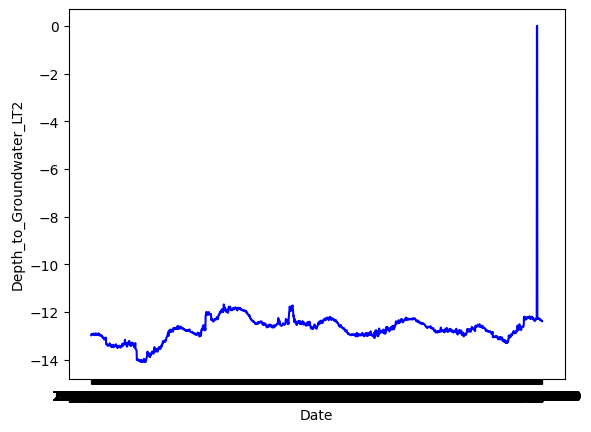

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(x=df['Date'], y=df['Depth_to_Groundwater_LT2'], color='blue')

In [ ]:
ts = ts[['Depth_to_Groundwater_LT2'<-12]]

ts